In [1]:
import scanpy as sc

In [2]:
adata = sc.read_h5ad('/home1/xyf/data/h5ad/NGS_genename.h5ad')

In [3]:
adata

AnnData object with n_obs × n_vars = 213961 × 36601
    obs: 'celltype', 'total_UMIs_NGS', 'developmental_system', 'sample', 'total_UMIs_ONT', 'embryos_id', 'stage', 'part'
    var: 'gene_ids', 'feature_type', 'ensembl_ids'
    uns: 'celltype_colors', 'developmental_system_colors'
    obsm: 'X_umap'

In [4]:
adata.var

,gene_ids,feature_type,ensembl_ids
gene_symbols,,,
MIR1302-2HG,ENSG00000243485,NaN,ENSG00000243485
FAM138A,ENSG00000237613,NaN,ENSG00000237613
OR4F5,ENSG00000186092,NaN,ENSG00000186092
AL627309.1,ENSG00000238009,NaN,ENSG00000238009
AL627309.3,ENSG00000239945,NaN,ENSG00000239945
...,...,...,...
AC010889.2,ENSG00000288049,NaN,ENSG00000288049
AC009494.2,ENSG00000286247,NaN,ENSG00000286247
AC010086.3,ENSG00000288057,NaN,ENSG00000288057


In [5]:
adata.obs

,celltype,total_UMIs_NGS,developmental_system,sample,total_UMIs_ONT,embryos_id,stage,part
barcode,,,,,,,,
h22-AAACCCACACTCTGCT,midhindbrain junction (MHB),4757,neural progenitor,h22,2005,emb6,CS14,H
h22-AAACCCACAGTTGCGC,dorsal telencephalon,3625,neural progenitor,h22,1553,emb6,CS14,H
h22-AAACCCACATGCCGCA,PA1/2 middle,10838,craniofacial,h22,5062,emb6,CS14,H
h22-AAACCCACATTGACCA,dorsal diencephalon,7911,neural progenitor,h22,3839,emb6,CS14,H
h22-AAACCCAGTGCCTAAT,dB3/dl5,2339,neuron,h22,1072,emb6,CS14,H
...,...,...,...,...,...,...,...,...
250530_01_VL-TTTGTTGGTCTGCGCA,hepatocyte,9127,endoderm,250530_01_VL,3120,emb9,CS15,V+L
250530_01_VL-TTTGTTGGTTTCCATT,somatic LPM-10,6668,somatic LPM,250530_01_VL,2239,emb9,CS15,V+L
250530_01_VL-TTTGTTGTCACGTCCT,anterior somatic LPM,3582,somatic LPM,250530_01_VL,1711,emb9,CS15,V+L


In [6]:
# 2. 预处理数据（在所有基因上进行）
# 归一化和对数化
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [7]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=500,
    batch_key="developmental_system"
)


In [8]:
sc.pp.scale(adata, max_value=10)

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import sparse

output_path = Path("/home1/xyf/project/github/OpenSpliceAI/data/developmental_system_hvg.csv")

hvg_mask = adata.var.get("highly_variable")
if hvg_mask is None:
    raise ValueError("adata.var['highly_variable'] not found; run sc.pp.highly_variable_genes first.")
if not np.any(hvg_mask):
    raise ValueError("No genes marked as highly variable.")

hvg_genes = adata.var_names[hvg_mask].tolist()
X = adata[:, hvg_genes].X
if sparse.issparse(X):
    X = X.toarray()

expr = pd.DataFrame(X, columns=hvg_genes, index=adata.obs_names)
expr["developmental_system"] = adata.obs["developmental_system"].astype(str).values
agg = expr.groupby("developmental_system").mean()

output_path.parent.mkdir(parents=True, exist_ok=True)
agg.to_csv(output_path)
print(f"Saved {agg.shape[0]} developmental systems x {agg.shape[1]} HVGs to {output_path}")



Saved 15 developmental systems x 500 HVGs to /home1/xyf/project/github/OpenSpliceAI/data/developmental_system_hvg.csv


In [10]:
agg

,HES5,NPPA,NPPB,HSPB7,MATN1,FABP3,DAB1,TACSTD2,NFIA,LRRC7,...,AC007391.3,IQCJ-SCHIP1,SOX2-OT,AC084740.1,AC022433.1,H19,DISC1FP1,RMST,AC004817.5,AC016168.4
developmental_system,,,,,,,,,,,,,,,,,,,,,
IM,-0.320108,-0.111931,-0.071778,-0.117587,0.052778,-0.123586,0.079028,-0.068716,0.288761,0.286411,...,-0.006767,0.435185,-0.170553,0.009653,-0.006107,0.949881,-0.132034,0.178333,-0.037140,0.018448
blood,-0.324355,-0.040284,-0.074833,-0.099327,-0.059029,0.172299,-0.453627,-0.118020,-0.362813,-0.198574,...,-0.030624,-0.204663,-0.308215,-0.009512,-0.075981,-0.300800,0.259333,-0.335317,0.073080,-0.028874
craniofacial,-0.330184,-0.099664,-0.091282,-0.121019,-0.012356,-0.153060,-0.000660,-0.027248,-0.016682,-0.111972,...,-0.028642,-0.079326,-0.243716,-0.032186,-0.033046,-0.072442,-0.046614,-0.291032,-0.027255,-0.021218
endoderm,-0.336540,0.084266,0.067494,0.040724,-0.019797,0.218999,-0.109478,0.225230,-0.348752,-0.116928,...,-0.013183,0.129093,-0.222351,-0.014736,-0.051563,0.908778,0.008493,-0.179966,-0.018514,-0.021780
endothelium,-0.289357,-0.019962,-0.040363,-0.090791,-0.033543,-0.114093,-0.332161,-0.092253,0.127309,-0.197894,...,-0.019180,0.701762,-0.276749,0.036599,-0.061440,0.260864,-0.079255,-0.321407,-0.016658,-0.005418
epidermis,-0.341001,-0.093276,0.049041,-0.120484,-0.021695,-0.174582,-0.231589,2.997944,-0.308085,0.149698,...,-0.040300,0.533222,-0.203791,0.033429,0.005236,0.206159,-0.054877,-0.145034,-0.027564,-0.020280
head mesoderm,-0.287626,-0.134277,-0.121245,-0.146230,-0.022205,-0.102832,-0.003862,-0.110710,-0.022365,0.087482,...,-0.029426,0.009892,-0.235658,-0.032593,-0.071194,-0.319747,-0.119508,-0.256634,-0.014027,-0.019000
limb,-0.348656,-0.085174,-0.103615,-0.124534,-0.008876,-0.176011,-0.041804,-0.124877,-0.005296,-0.154730,...,-0.034309,-0.144453,-0.275903,-0.037215,-0.023070,-0.158038,0.017415,-0.321988,-0.029188,-0.020875
neural progenitor,1.409304,-0.135172,-0.115659,-0.149635,-0.029564,-0.171355,0.308843,0.022836,-0.262030,-0.107201,...,-0.006286,-0.053309,0.778146,-0.028467,-0.067966,-0.400239,0.117842,1.011191,-0.019439,-0.028229


In [11]:
import seaborn as sns

<Figure size 1800x1000 with 0 Axes>

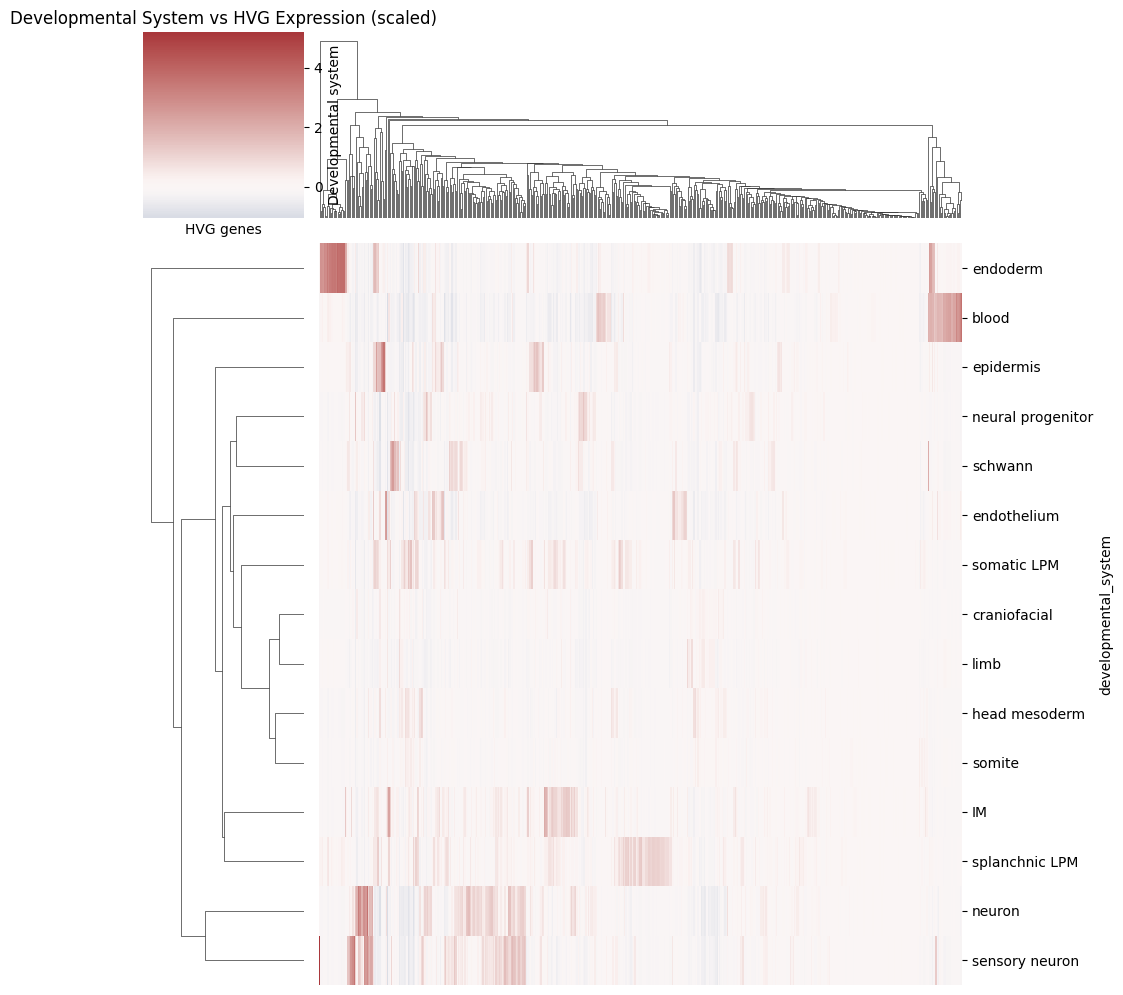

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 10))
sns.clustermap(agg, cmap="vlag", center=0, xticklabels=False)
plt.title("Developmental System vs HVG Expression (scaled)")
plt.xlabel("HVG genes")
plt.ylabel("Developmental system")
plt.tight_layout()
plt.show()



<Figure size 1800x1000 with 0 Axes>

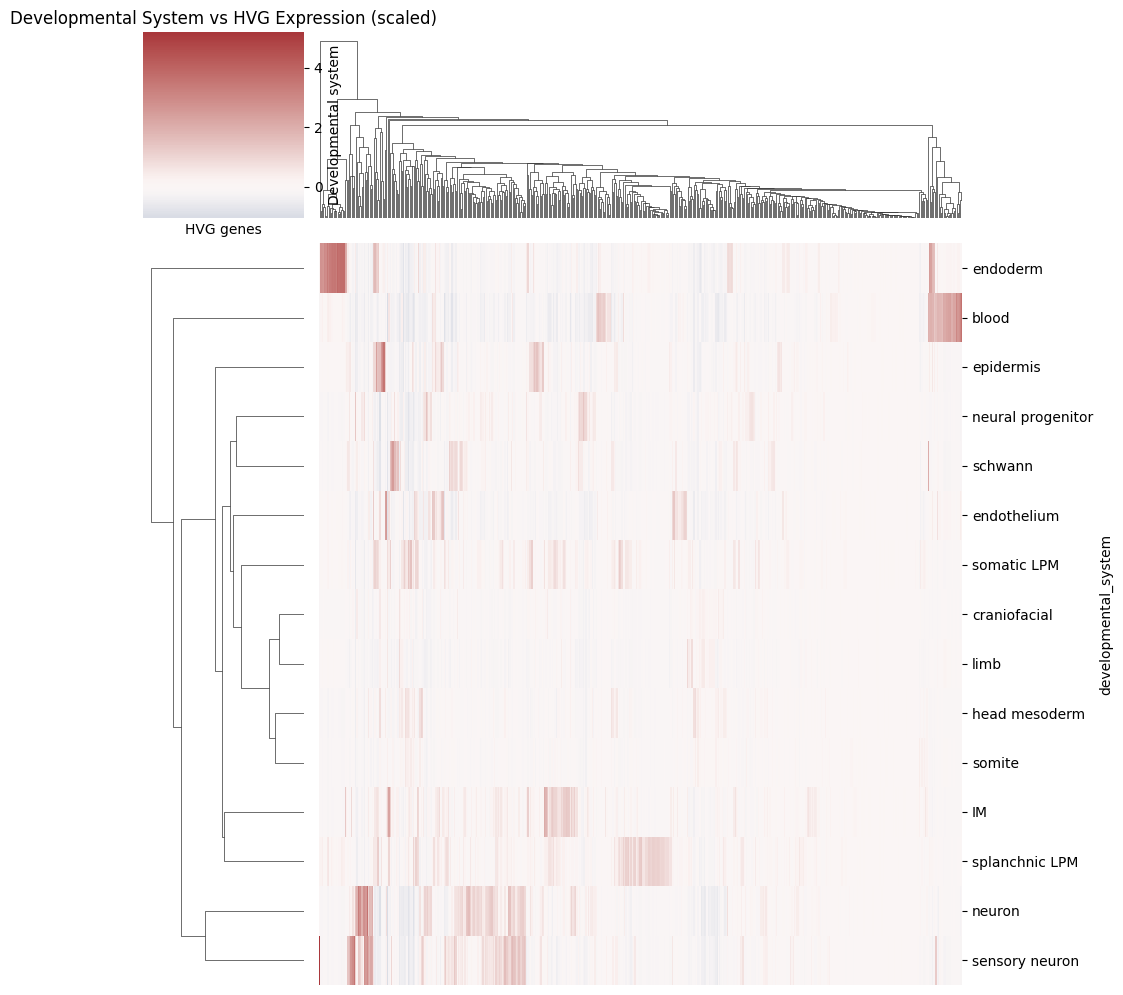

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 10))
sns.clustermap(agg, cmap="vlag", center=0, xticklabels=False)
plt.title("Developmental System vs HVG Expression (scaled)")
plt.xlabel("HVG genes")
plt.ylabel("Developmental system")
plt.tight_layout()
plt.show()



In [38]:
adata.obs.loc[:,'developmental_system'].value_counts()

developmental_system
somite               45216
neural progenitor    37601
limb                 22935
craniofacial         22435
splanchnic LPM       22063
head mesoderm        14551
somatic LPM          11655
neuron                7271
blood                 6069
schwann               5423
endothelium           5217
epidermis             4650
endoderm              4174
sensory neuron        3688
IM                    1013
Name: count, dtype: int64